# Music Genre Classification and Recommendation System

**Authors:** Kaelynn Lackey, Will Sun  
**Date:** December 4, 2025  
**Course:** DS4400 - Machine Learning & Data Mining

## 1. Data Loading and Preprocessing

### 1.1 Import Libraries

In [4]:
# necessary data libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
confusion_matrix, ConfusionMatrixDisplay)
from itertools import product
import ast
import warnings
warnings.filterwarnings('ignore')

### 1.2 Load Dataset

In [6]:
# set random seed for reproducibility
np.random.seed(42)

# provides a consistent style for all of the plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [7]:
# load the dataset with genre information/audio features
df = pd.read_csv('data_w_genres.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (28680, 16)

First few rows:


,genres,artists,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key,mode,count
0,['show tunes'],"""Cats"" 1981 Original London Cast",0.590111,0.467222,250318.555556,0.394003,0.011400,0.290833,-14.448000,0.210389,117.518111,0.389500,38.333333,5,1,9
1,[],"""Cats"" 1983 Broadway Cast",0.862538,0.441731,287280.000000,0.406808,0.081158,0.315215,-10.690000,0.176212,103.044154,0.268865,30.576923,5,1,26
2,[],"""Fiddler On The Roof” Motion Picture Chorus",0.856571,0.348286,328920.000000,0.286571,0.024593,0.325786,-15.230714,0.118514,77.375857,0.354857,34.857143,0,1,7
3,[],"""Fiddler On The Roof” Motion Picture Orchestra",0.884926,0.425074,262890.962963,0.245770,0.073587,0.275481,-15.639370,0.123200,88.667630,0.372030,34.851852,0,1,27
4,[],"""Joseph And The Amazing Technicolor Dreamcoat""...",0.510714,0.467143,270436.142857,0.488286,0.009400,0.195000,-10.236714,0.098543,122.835857,0.482286,43.000000,5,1,7


In [8]:
# helps us identify missing values and data types
print("Dataset Information:")
print(df.info())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28680 entries, 0 to 28679
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   genres            28680 non-null  object 
 1   artists           28680 non-null  object 
 2   acousticness      28680 non-null  float64
 3   danceability      28680 non-null  float64
 4   duration_ms       28680 non-null  float64
 5   energy            28680 non-null  float64
 6   instrumentalness  28680 non-null  float64
 7   liveness          28680 non-null  float64
 8   loudness          28680 non-null  float64
 9   speechiness       28680 non-null  float64
 10  tempo             28680 non-null  float64
 11  valence           28680 non-null  float64
 12  popularity        28680 non-null  float64
 13  key               28680 non-null  int64  
 14  mode              28680 non-null  int64  
 15  count             28680 non-null  int64  
dtypes: float64(11), int

In [9]:
# helps us check ranges and outliers
print("Statistical Summary:")
df.describe()

Statistical Summary:


,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key,mode,count
count,28680.000000,28680.000000,2.868000e+04,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000
mean,0.498373,0.546490,2.388780e+05,0.497488,0.174756,0.202441,-11.140498,0.094014,115.844830,0.512723,34.060945,5.412901,0.759170,13.847211
std,0.370614,0.176474,1.211318e+05,0.254885,0.298406,0.140884,5.771749,0.111986,25.003834,0.244421,22.376438,3.480552,0.427595,53.372544
min,0.000000,0.000000,1.879550e+04,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.122296,0.431000,1.823304e+05,0.283568,0.000004,0.110362,-13.972292,0.039200,99.366500,0.329000,12.000000,2.000000,1.000000,2.000000
50%,0.478458,0.557000,2.186400e+05,0.504000,0.001880,0.161000,-10.088938,0.052200,115.357400,0.523243,39.000000,6.000000,1.000000,3.000000
75%,0.896000,0.675000,2.684670e+05,0.702783,0.215291,0.247000,-6.889000,0.095300,129.848750,0.703000,51.000000,8.000000,1.000000,8.000000
max,0.996000,0.986000,5.403500e+06,1.000000,1.000000,0.991000,1.342000,0.964000,217.743000,0.991000,93.000000,11.000000,1.000000,3169.000000


### 1.3 Data Cleaning

### 1.4 Genre Extraction and Filtering

In [12]:
# checks for missing values
print(f"Missing values per column: {df.isnull().sum()}")

feature_cols =["danceability", "energy", "loudness", "speechiness","acousticness", 
               "instrumentalness", "liveness","valence", "tempo", "duration_ms", "popularity"]

# drops rows with any missing critical numeric features
# first cleaning step: remove incomplete observations
df_clean=df.dropna(subset=feature_cols +['genres'])
print(f"\nRows after dropping missing values: {len(df_clean)}")

Missing values per column: genres              0
artists             0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
key                 0
mode                0
count               0
dtype: int64

Rows after dropping missing values: 28680


In [13]:
# parses genre strings and extracts primary genre
# each genre is stored as a string representation of lists: "['pop','dance pop']" etc.
# addresses class imbalance and simplifies the classification step

def extract_primary_genre(genre_str):
    """extracts the first genre from a genre list string."""
    try:
        genre_list= ast.literal_eval(genre_str)
        if isinstance(genre_list,list) and len(genre_list)> 0:
            return genre_list[0].strip().lower()
        else:
            return None
    except:
        return None # we treat any entry that cannot be parsed as missing

# applies genre extraction to each row
df_clean['genre']=df_clean['genres'].apply(extract_primary_genre)

# drop rows with no valid genre key
# second cleaning step: remove invalid genre keys
df_clean = df_clean.dropna(subset=['genre'])
print(f"Rows after removing empty genres: {len(df_clean)}")
print(f"\nNumber of unique genres: {df_clean['genre'].nunique()}")

Rows after removing empty genres: 18823

Number of unique genres: 1997


In [14]:
# shows the genre distribution
genre_counts = df_clean['genre'].value_counts()
print(f"Top 20 genres by frequency: \n{genre_counts.head(20)}")

Top 20 genres by frequency: 
genre
dance pop                397
adult standards          334
album rock               313
alternative metal        296
latin                    246
contemporary country     221
alternative rock         174
corrido                  170
alternative hip hop      161
classic soul             153
broadway                 140
alternative r&b          135
atl hip hop              134
classical performance    129
bebop                    127
alternative dance        127
brill building pop       120
classical                115
c-pop                    115
funk                     108
Name: count, dtype: int64


In [15]:
# filters to top N genres for class balance
# we chose top 12 genres to have enough classes while maintaining reasonable 
# sample sizes
TOP_N=12
top_genres= genre_counts.head(TOP_N).index.tolist()

# we filter rows whose genre is among the top N
df_filtered =df_clean[df_clean['genre'].isin(top_genres)].copy()

print(f"\nFiltered to top {TOP_N} genres")
print(f"Final dataset size: {len(df_filtered)}")
print(f"\nGenre distribution after filtering:\n{df_filtered['genre'].value_counts()}")


Filtered to top 12 genres
Final dataset size: 2740

Genre distribution after filtering:
genre
dance pop               397
adult standards         334
album rock              313
alternative metal       296
latin                   246
contemporary country    221
alternative rock        174
corrido                 170
alternative hip hop     161
classic soul            153
broadway                140
alternative r&b         135
Name: count, dtype: int64


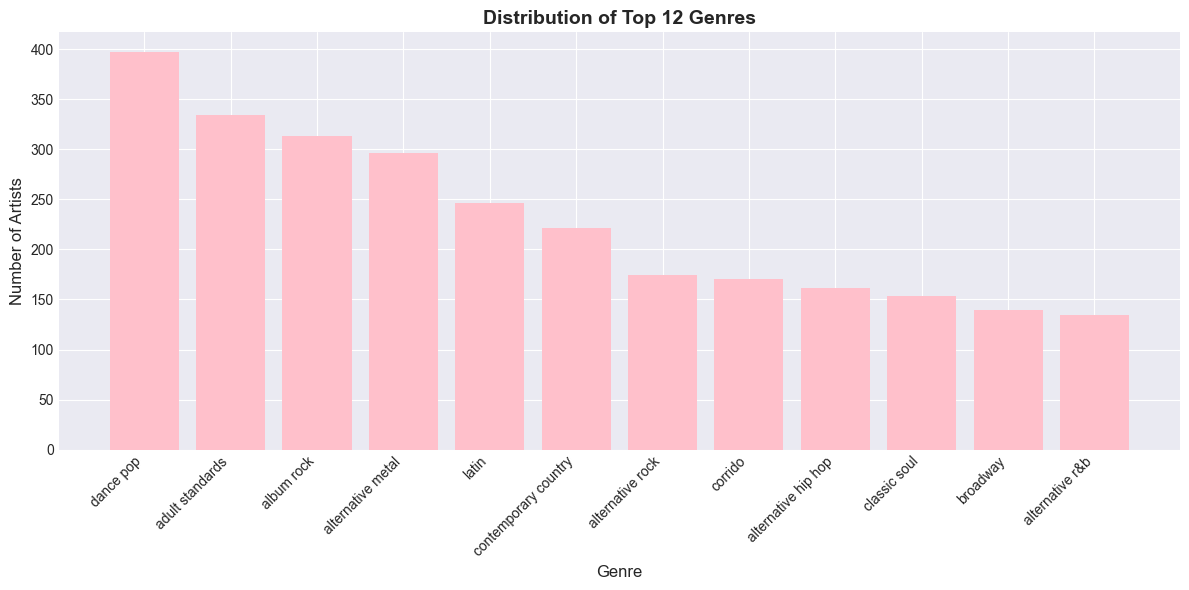

In [16]:
# visualization of distribution of the top 12 genres after filtering 
plt.figure(figsize=(12,6))
genre_counts_filtered =df_filtered['genre'].value_counts()
plt.bar(range(len(genre_counts_filtered)),genre_counts_filtered.values,color='pink')
plt.xticks(range(len(genre_counts_filtered)), genre_counts_filtered.index,rotation=45,ha='right')
plt.xlabel('Genre',fontsize=12)
plt.ylabel('Number of Artists', fontsize=12)
plt.title(f'Distribution of Top {TOP_N} Genres',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

### 1.6 Train/Val/Test Split

In [19]:
# define feature set (11 audio features)
# these columns will be the input to the classifiers
feature_cols=["danceability","energy","loudness", "speechiness","acousticness",
                "instrumentalness", "liveness","valence","tempo", "duration_ms","popularity"]

# extracts features and labels from the cleaned dataset
X = df_filtered[feature_cols].copy()
y = df_filtered['genre'].copy()
print(f"Feature matrix shape:{X.shape}")
print(f"Label vector shape: {y.shape}")
print(f"\nFeature columns: {feature_cols}")

Feature matrix shape:(2740, 11)
Label vector shape: (2740,)

Feature columns: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'popularity']


In [20]:
# encode labels using LabelEncoder
# required step for scikit learn classifiers
label_encoder=LabelEncoder()
y_encoded =label_encoder.fit_transform(y)

print(f"Genre to label mapping:")
for i, genre in enumerate(label_encoder.classes_):
    print(f"{i}: {genre}")

Genre to label mapping:
0: adult standards
1: album rock
2: alternative hip hop
3: alternative metal
4: alternative r&b
5: alternative rock
6: broadway
7: classic soul
8: contemporary country
9: corrido
10: dance pop
11: latin


In [21]:
# Train/Val/Test split 
# first split: 70% train, 30% temp (val + test)
X_train, X_temp,y_train,y_temp=train_test_split(X,y_encoded,test_size=0.3,
                                                 stratify=y_encoded,random_state=42)

# second split: 50/50 split of temp into val and test (15% each of total)
X_val,X_test,y_val,y_test=train_test_split(X_temp,y_temp,test_size=0.5, 
                                                stratify=y_temp,random_state=42)

print(f"The size of the training set: {X_train.shape[0]}({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"The size of the validation set: {X_val.shape[0]}({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"The size of the test set: {X_test.shape[0]}({X_test.shape[0]/len(X)*100:.1f}%)")

The size of the training set: 1918(70.0%)
The size of the validation set: 411(15.0%)
The size of the test set: 411(15.0%)


In [22]:
# standardize features 
# Logistic Regression benefits from scaling, but it not necessary for Random Forest
# We create both scaled and unscaled versions
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## 2. Modeling

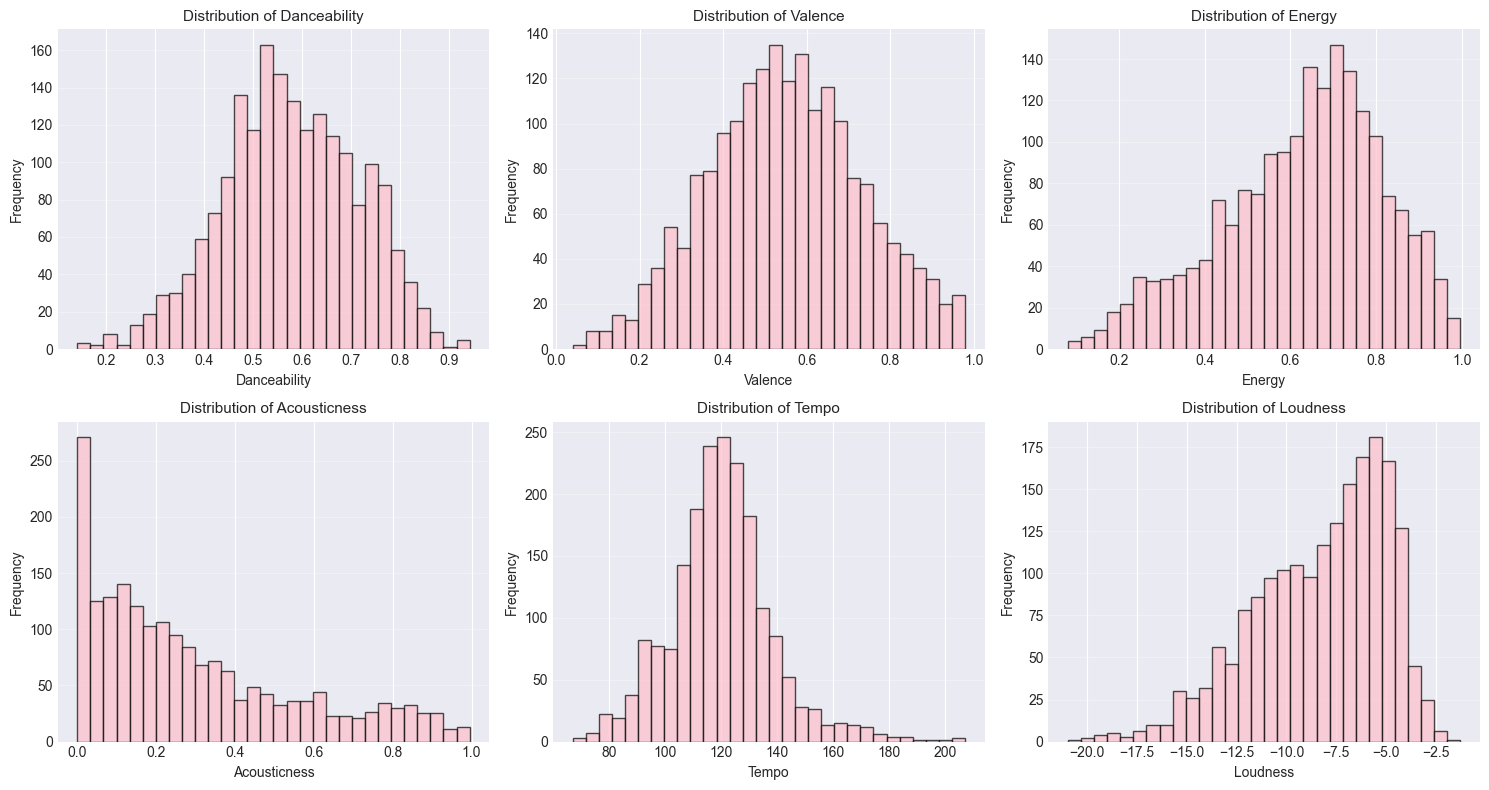

In [24]:
# visual distribution of key features on the training set
fig, axes=plt.subplots(2, 3, figsize=(15, 8))
features_to_plot=['danceability','valence', 'energy','acousticness','tempo','loudness']

for i,feature in enumerate(features_to_plot):
    ax= axes[i// 3,i % 3]
    ax.hist(X_train[feature],bins=30,color='pink',edgecolor='black',alpha=0.7)
    ax.set_xlabel(feature.capitalize(),fontsize=10)
    ax.set_ylabel('Frequency',fontsize=10)
    ax.set_title(f'Distribution of {feature.capitalize()}',fontsize=11)
    ax.grid(axis='y',alpha=0.3)

plt.tight_layout()
plt.show()

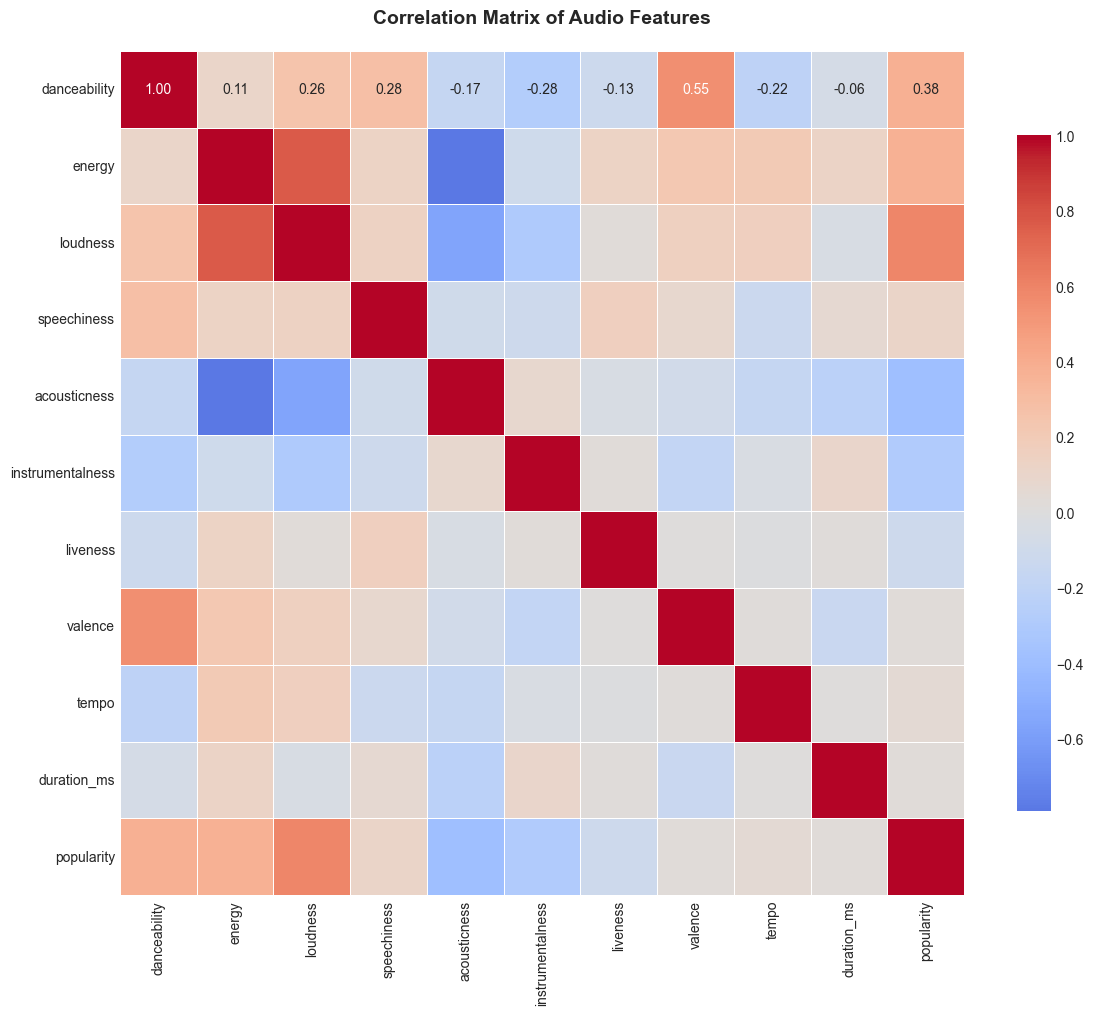

In [25]:
# Correlation heatmap of audio features
# helped us identify strongly correlated features and potential redundancy
plt.figure(figsize=(12,10))
correlation_matrix=X_train.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f',cmap='coolwarm',center=0,square=True,
            linewidths=0.5,cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Audio Features',fontsize=14,fontweight='bold',pad=20)
plt.tight_layout()
plt.show()

### 2.1 Logistic Regression

In [27]:
# Training the logistic regression model with different C values (regularization strength)
# Smaller C values impose stronger regularization to reduce overfitting
C_values =[0.1,1,10]
best_c= None
best_f1 =0
results_lr={}

for C in C_values:
    lr= LogisticRegression(multi_class='multinomial',
        max_iter=1000,
        class_weight='balanced', #helps with class balance
        C=C,random_state=42)
    lr.fit(X_train_scaled,y_train)
    
    # evaluation metrics on the validation set
    # used to tune C and prevent overfitting
    y_val_pred =lr.predict(X_val_scaled)
    val_acc=accuracy_score(y_val, y_val_pred)
    val_f1=f1_score(y_val,y_val_pred,average='macro')
    results_lr[C]={'accuracy': val_acc,'f1': val_f1,'model': lr}
    print(f"C={C}: validation accuracy:{val_acc:.4f}, f1:{val_f1:.4f}")
    
    # keeps track of the best model/optimal value of C
    if val_f1 >best_f1:
        best_f1 = val_f1
        best_c=C
print(f"\nBest C: {best_c} with F1:{best_f1:.4f}")
lr_best=results_lr[best_c]['model']

C=0.1: validation accuracy:0.5353, f1:0.5177
C=1: validation accuracy:0.5474, f1:0.5323
C=10: validation accuracy:0.5474, f1:0.5332

Best C: 10 with F1:0.5332


## 3. Results

In [29]:
# Random Forest hyperparameter grid search
# we tune the number of trees, max depth and min samples per split
param_grid= {'n_estimators':[200, 300],
    'max_depth':[None, 20],
    'min_samples_split':[2, 5]}

best_rf_f1=0
best_rf_params=None
results_rf=[]

# iterates through all parameter combinations
for n_est,max_d, min_split in product(
    param_grid['n_estimators'],
    param_grid['max_depth'],
    param_grid['min_samples_split']):
    
    # trains random forest on each parameter
    rf = RandomForestClassifier(n_estimators=n_est,
                                max_depth=max_d,
                                min_samples_split=min_split,
                                class_weight='balanced',
                                random_state=42,
                                n_jobs=-1)
    rf.fit(X_train,y_train)
    # evaluates the random forest on the validation set
    y_val_pred =rf.predict(X_val)
    val_acc =accuracy_score(y_val,y_val_pred)
    val_f1=f1_score(y_val,y_val_pred, average='macro')
    
    results_rf.append({'n_estimators':n_est,'max_depth': max_d,
        'min_samples_split': min_split,'accuracy': val_acc,
        'f1': val_f1,'model': rf})
    
    max_d_str=str(max_d) if max_d else "None"
    # keeps track of the best mdoel
    if val_f1 >best_rf_f1:
        best_rf_f1 = val_f1
        best_rf_params={'n_estimators': n_est,'max_depth': max_d,'min_samples_split': min_split}
        rf_best=rf

print(f"Best Random Forest parameters: {best_rf_params}")
print(f"Best validation F1: {best_rf_f1:.4f}")

Best Random Forest parameters: {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 2}
Best validation F1: 0.6284


### 3.3 Example Recommendations

In [31]:
# Prepare data for recommender system
# We'll use the full filtered dataset (not split into train/val/test)
X_all = df_filtered[feature_cols].copy()
y_all = df_filtered['genre'].copy()
artists_all = df_filtered['artists'].values

# Scale all features for cosine similarity computation
X_all_scaled = scaler.transform(X_all)

print(f"Recommender dataset size: {len(X_all)} songs")
print(f"Feature dimension: {X_all.shape[1]}")

Recommender dataset size: 2740 songs
Feature dimension: 11


### 2.3 Recommender System

In [33]:
def recommend_songs(query_idx,k=5,use_predicted_genre=True):
    """
    Recommend top-k similar songs based on audio features and genre.
    
    Parameters:
    query_idx : int
        Index of the query song in df_filtered
    k : int
        Number of recommendations to return
    use_predicted_genre : bool
        If True, use RF predicted genre. If False, use true genre.
    
    Returns:
    recommendations : DataFrame
        Top-k recommended songs with their features
    distances : array
        Cosine distances to recommended songs
    """
    x_query = X_all_scaled[query_idx].reshape(1, -1)
    
    if use_predicted_genre:
        # uses the best random forest model to make recommendations
        x_query_unscaled=X_all.iloc[[query_idx]]
        pred_genre_encoded=rf_best.predict(x_query_unscaled)[0]
        pred_genre =label_encoder.inverse_transform([pred_genre_encoded])[0]
    else:
        pred_genre=y_all.iloc[query_idx]
    
    # filters candidate by genre
    mask=(y_all== pred_genre).values
    X_candidates_scaled=X_all_scaled[mask]
    idx_candidates=np.where(mask)[0]
    
    # prints a warning if there is not enough candidates
    if len(idx_candidates) < k + 1:
        print(f"Warning: only {len(idx_candidates)} songs in genre '{pred_genre}'")
        k_actual= min(k,len(idx_candidates) - 1)
    else:
        k_actual=k
    
    # fits knn on candidates
    knn= NearestNeighbors(metric='cosine',n_neighbors=k_actual+1)
    knn.fit(X_candidates_scaled)
    
    # finds the nearest neighbors
    distances,indices =knn.kneighbors(x_query)
    rec_indices=idx_candidates[indices[0]]
    rec_distances =distances[0]
    
    # filters out the query song itself
    mask_not_self=rec_indices != query_idx
    rec_indices=rec_indices[mask_not_self][:k]
    rec_distances=rec_distances[mask_not_self][:k]
    
    # returns the recommendations
    recommendations = df_filtered.iloc[rec_indices].copy()
    recommendations['cosine_distance']=rec_distances
    recommendations['cosine_similarity']=1 -rec_distances
    return recommendations,pred_genre


In [34]:
# Evaluate both models on test set
print("final test set evalution on both models:")

# logistic regression
y_test_pred_lr=lr_best.predict(X_test_scaled)
test_acc_lr=accuracy_score(y_test, y_test_pred_lr)
test_f1_lr=f1_score(y_test, y_test_pred_lr,average='macro')
print("\nLogistic Regression (as a baseline):")
print(f"test accuracy: {test_acc_lr}")
print(f"test f1 score: {test_f1_lr}")

# Random Forest
y_test_pred_rf=rf_best.predict(X_test)
test_acc_rf=accuracy_score(y_test,y_test_pred_rf)
test_f1_rf =f1_score(y_test,y_test_pred_rf, average='macro')
print("\nRandom Forest (Main Model):")
print(f"test accuracy:{test_acc_rf}")
print(f"test F1:{test_f1_rf}\n")

print("Model Comparison: ")
accuracy_percent=round((test_acc_rf/test_acc_lr-1)*100,3)
print(f"Accuracy Improvement:{round((test_acc_rf-test_acc_lr),3)}(+{accuracy_percent}%)")
f1_percent= round((test_f1_rf/test_f1_lr - 1)*100,3)
print(f"F1 Improvement:{round((test_f1_rf-test_f1_lr),3)}(+{f1_percent}%)\n")

# Define genre names for confusion matrix
genre_names=label_encoder.inverse_transform(range(len(label_encoder.classes_)))

final test set evalution on both models:

Logistic Regression (as a baseline):
test accuracy: 0.5717761557177615
test f1 score: 0.5522907222173673

Random Forest (Main Model):
test accuracy:0.681265206812652
test F1:0.6554798444645412

Model Comparison: 
Accuracy Improvement:0.109(+19.149%)
F1 Improvement:0.103(+18.684%)



<Figure size 2000x2000 with 0 Axes>

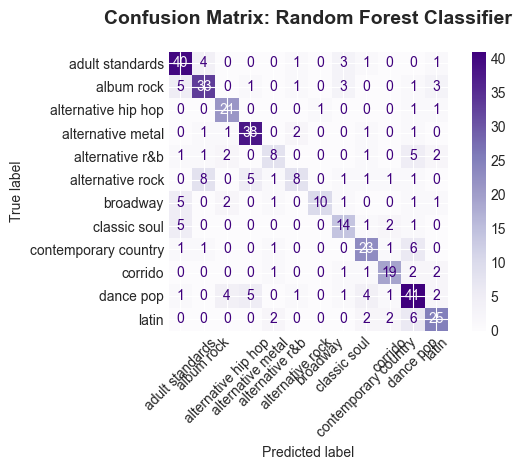

In [35]:
# confusion matrix for Random Forest
# shows which genres are confused with each other
cm=confusion_matrix(y_test,y_test_pred_rf)
plt.figure(figsize=(20,20))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=genre_names)
disp.plot(cmap='Purples',values_format='d',xticks_rotation=45)
plt.title('Confusion Matrix: Random Forest Classifier',fontsize=14,fontweight='bold',pad=20)
plt.tight_layout()
plt.show()


Feature Importances:
         feature  importance
     speechiness    0.122588
    acousticness    0.119003
      popularity    0.111134
    danceability    0.095803
         valence    0.095434
          energy    0.093258
     duration_ms    0.080899
        loudness    0.079770
instrumentalness    0.076784
           tempo    0.066677
        liveness    0.058651



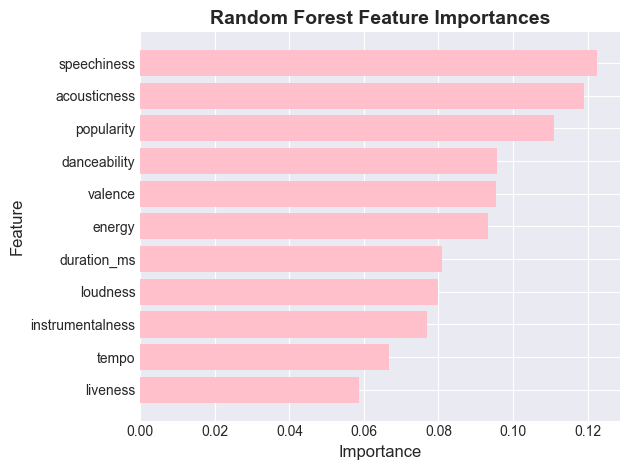

In [36]:
# Feature importance from tuned Random Forest
# higher importance means the feature contributed more to genre prediction
feature_importance=rf_best.feature_importances_
feature_importance_df =pd.DataFrame({'feature': feature_cols,
                                      'importance': feature_importance}).sort_values('importance',
                                                                                     ascending=False)
print(f"\nFeature Importances:\n{feature_importance_df.to_string(index=False)}\n")

plt.barh(range(len(feature_importance_df)),feature_importance_df['importance'],color='pink')
plt.yticks(range(len(feature_importance_df)),feature_importance_df['feature'])
plt.xlabel('Importance',fontsize=12)
plt.ylabel('Feature',fontsize=12)
plt.title('Random Forest Feature Importances',fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [37]:
# Quantitative evaluation using average cosine similarity

# Sample 100 random songs to compare three methods:
# 1) random song globally
# 2) random songs within the same genre
# 3) Our recommender

np.random.seed(42)
sample_indices=np.random.choice(len(X_all),size=min(100,len(X_all)),replace=False)

similarities_recommender=[]
similarities_random_global=[]
similarities_random_genre=[]
for idx in sample_indices:
    recs,pred_genre=recommend_songs(idx,k=5,use_predicted_genre=True)
    similarities_recommender.extend(recs['cosine_similarity'].values)
    
    # first baseline: random songs globally
    random_global_idx=np.random.choice(len(X_all),size=5,replace=False)
    random_global_idx=[i for i in random_global_idx if i != idx][:5]
    x_query=X_all_scaled[idx].reshape(1, -1)
    for ridx in random_global_idx:
        x_random=X_all_scaled[ridx].reshape(1, -1)
        cos_sim=1-np.dot(x_query,x_random.T)[0,0]/(np.linalg.norm(x_query)
                                                    *np.linalg.norm(x_random))
        similarities_random_global.append(1-cos_sim)
    
    # second baseline: random songs within same genre
    true_genre =y_all.iloc[idx]
    same_genre_mask =(y_all ==true_genre).values
    same_genre_indices=np.where(same_genre_mask)[0]
    same_genre_indices=[i for i in same_genre_indices if i!= idx]
    if len(same_genre_indices)>= 5:
        random_genre_idx =np.random.choice(same_genre_indices,size=5,replace=False)
        for ridx in random_genre_idx:
            x_random=X_all_scaled[ridx].reshape(1, -1)
            cos_sim =1-np.dot(x_query,x_random.T)[0, 0] /(np.linalg.norm(x_query)*np.linalg.norm(x_random))
            similarities_random_genre.append(1 - cos_sim)

# compute average similarities
avg_sim_recommender=np.mean(similarities_recommender)
avg_sim_random_global=np.mean(similarities_random_global)
avg_sim_random_genre=np.mean(similarities_random_genre)

print("Recommender Performance using Average Cosine Similarity:\n")
print(f"{'Method':<20} {'Avg Cosine Similarity':>20}")
print(f"{'Random songs (global)':<20} {avg_sim_random_global:>20}")
print(f"{'Random songs (same genre)':<20}{avg_sim_random_genre:>20}")
print(f"{'Our recommender (RF + KNN)':<20}{avg_sim_recommender:>20}")

Recommender Performance using Average Cosine Similarity:

Method               Avg Cosine Similarity
Random songs (global) 0.031298300263010025
Random songs (same genre) 0.29188366613703604
Our recommender (RF + KNN)  0.8556548313079759


In [65]:
# qualitative evaluation using example recommendations

# select 3 diverse example songs
# shows the top 5 recommendations chosen by our recommender for each song
example_indices=[100, 500, 1000] 

for i, idx in enumerate(example_indices, 1):
    print(f"example #{i}: query song")    

    query_song = df_filtered.iloc[idx]
    print(f"Artist:{query_song['artists']}")
    print(f"True genre: {query_song['genre']}")
    print(f"\nAudio Features:")
    print(f"Energy:{query_song['energy']:.3f}")
    print(f"Valence:{query_song['valence']:.3f}")
    print(f"Danceability: {query_song['danceability']:.3f}")
    print(f"Acousticness:{query_song['acousticness']:.3f}")
    print(f"Tempo: {query_song['tempo']:.1f} BPM")
    
    # returns the recommendations
    recs,pred_genre = recommend_songs(idx, k=5, use_predicted_genre=True)
    print(f"\nPredicted Genre:{pred_genre}")
    print(f"\nTop 5 Recommendations:")
    
    for j, (_,rec) in enumerate(recs.iterrows(), 1):
        print(f"\n{j}.{rec['artists']}")
        print(f"Genre:{rec['genre']}")
        print(f"Similarity:{rec['cosine_similarity']:.4f}")
        print(f"Features: Energy={rec['energy']:.3f}, Valence={rec['valence']:.3f},"
              f"Dance={rec['danceability']:.3f},Tempo={rec['tempo']:.1f}")

example #1: query song
Artist:Ambrosia
True genre: adult standards

Audio Features:
Energy:0.634
Valence:0.673
Danceability: 0.536
Acousticness:0.183
Tempo: 127.4 BPM

Predicted Genre:adult standards

Top 5 Recommendations:

1.Boz Scaggs
Genre:adult standards
Similarity:0.6334
Features: Energy=0.569, Valence=0.545,Dance=0.553,Tempo=123.0

2.Connie
Genre:adult standards
Similarity:0.5743
Features: Energy=0.742, Valence=0.887,Dance=0.846,Tempo=117.7

3.The Belmonts
Genre:adult standards
Similarity:0.5390
Features: Energy=0.591, Valence=0.960,Dance=0.662,Tempo=120.3

4.Barry White
Genre:adult standards
Similarity:0.5345
Features: Energy=0.522, Valence=0.645,Dance=0.605,Tempo=104.4

5.Ritchie
Genre:adult standards
Similarity:0.5262
Features: Energy=0.765, Valence=0.750,Dance=0.611,Tempo=124.5
example #2: query song
Artist:Commodores
True genre: adult standards

Audio Features:
Energy:0.525
Valence:0.577
Danceability: 0.627
Acousticness:0.332
Tempo: 116.3 BPM

Predicted Genre:album rock

To